In [1]:
pip -q install earthaccess antimeridian

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pathlib
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import antimeridian
import earthaccess
import xarray as xr

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
auth = earthaccess.login(persist=True)

In [4]:
colocated_tracks = gpd.read_parquet("orcestra_coloc_ec.parquet")

In [5]:
colocated_tracks

,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,timestr,...,date,start_time,end_time,enclosure_ACM_CAP_2B,enclosure_AC__TC__2B,enclosure_ACM_RT__2B,enclosure_ALL_DF__2B,enclosure_ATL_EBD_2A,enclosure_CPR_CD__2A,enclosure_CPR_FMR_2A
14744,19,84,618.000000,493.000000,1,5,5.546984,14745,2024-08-10 09:30:00,2024-08-10 09:30:00,...,2024-08-10 09:42:18,2024-08-10 09:42:18,2024-08-10 09:53:54,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
35492,41,1289,2589.000000,520.300000,10,20,25.310354,35493,2024-08-10 20:30:00,2024-08-10 20:30:00,...,2024-08-10 20:30:32,2024-08-10 20:30:32,2024-08-10 20:42:08,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
35675,42,155,750.000000,662.000000,1,5,5.148579,35676,2024-08-10 21:00:00,2024-08-10 21:00:00,...,2024-08-10 21:05:00,2024-08-10 21:05:00,2024-08-10 21:16:47,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
36208,42,945,745.000000,638.000000,1,10,11.937240,36209,2024-08-10 21:00:00,2024-08-10 21:00:00,...,2024-08-10 21:05:00,2024-08-10 21:05:00,2024-08-10 21:16:47,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
63681,73,297,2001.000000,484.833333,6,5,7.213697,63682,2024-08-11 12:30:00,2024-08-11 12:30:00,...,2024-08-11 12:42:49,2024-08-11 12:42:49,2024-08-11 12:54:25,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193453,2488,580,2666.000000,676.000000,1,5,6.325706,2193454,2024-09-30 20:00:00,2024-09-30 20:00:00,...,2024-09-30 19:58:29,2024-09-30 19:58:29,2024-09-30 20:10:15,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2194102,2489,112,744.000000,96.000000,1,5,5.061385,2194103,2024-09-30 20:30:00,2024-09-30 20:30:00,...,2024-09-30 20:44:41,2024-09-30 20:44:41,2024-09-30 20:56:30,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2194899,2489,1195,833.153846,542.692308,13,20,28.502623,2194900,2024-09-30 20:30:00,

In [6]:
colocated_tracks.rename({"index_ec":"index"})

,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,timestr,...,date,start_time,end_time,enclosure_ACM_CAP_2B,enclosure_AC__TC__2B,enclosure_ACM_RT__2B,enclosure_ALL_DF__2B,enclosure_ATL_EBD_2A,enclosure_CPR_CD__2A,enclosure_CPR_FMR_2A
14744,19,84,618.000000,493.000000,1,5,5.546984,14745,2024-08-10 09:30:00,2024-08-10 09:30:00,...,2024-08-10 09:42:18,2024-08-10 09:42:18,2024-08-10 09:53:54,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
35492,41,1289,2589.000000,520.300000,10,20,25.310354,35493,2024-08-10 20:30:00,2024-08-10 20:30:00,...,2024-08-10 20:30:32,2024-08-10 20:30:32,2024-08-10 20:42:08,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
35675,42,155,750.000000,662.000000,1,5,5.148579,35676,2024-08-10 21:00:00,2024-08-10 21:00:00,...,2024-08-10 21:05:00,2024-08-10 21:05:00,2024-08-10 21:16:47,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
36208,42,945,745.000000,638.000000,1,10,11.937240,36209,2024-08-10 21:00:00,2024-08-10 21:00:00,...,2024-08-10 21:05:00,2024-08-10 21:05:00,2024-08-10 21:16:47,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
63681,73,297,2001.000000,484.833333,6,5,7.213697,63682,2024-08-11 12:30:00,2024-08-11 12:30:00,...,2024-08-11 12:42:49,2024-08-11 12:42:49,2024-08-11 12:54:25,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193453,2488,580,2666.000000,676.000000,1,5,6.325706,2193454,2024-09-30 20:00:00,2024-09-30 20:00:00,...,2024-09-30 19:58:29,2024-09-30 19:58:29,2024-09-30 20:10:15,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2194102,2489,112,744.000000,96.000000,1,5,5.061385,2194103,2024-09-30 20:30:00,2024-09-30 20:30:00,...,2024-09-30 20:44:41,2024-09-30 20:44:41,2024-09-30 20:56:30,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2194899,2489,1195,833.153846,542.692308,13,20,28.502623,2194900,2024-09-30 20:30:00,

In [7]:
bounds = shapely.Polygon(
    [[-180,-30], [-180,30], [180,30], [180,-30]]
)

In [9]:
n20_results = earthaccess.search_data(
    short_name="SNDRJ1ML2RMS", 
    temporal=("2024-08-18", "2024-08-18"),
    bounding_box=bounds.bounds, 
)

/opt/conda/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [15]:
n20_gdf = get_sounder_gdf(n20_results)

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

<GeoAxes: >

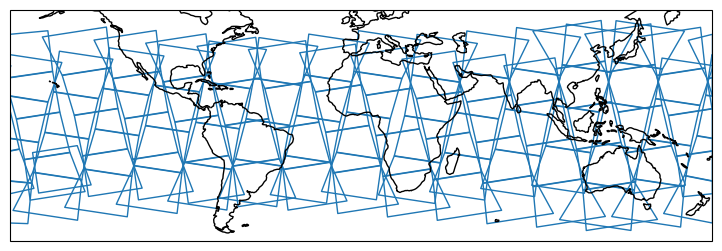

In [23]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax.coastlines()
n20_gdf.plot(ax=ax, facecolor="none", edgecolor="C0")

In [9]:
n20_results = earthaccess.search_data(
    short_name="SNDRJ1ML2RMS", 
    temporal=(colocated_tracks.time.min(), colocated_tracks.time.max()),
    bounding_box=bounds.bounds, 
)

/opt/conda/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [10]:
def get_sounder_gdf(results):
    borders = [
        r["umm"]["SpatialExtent"]["HorizontalSpatialDomain"]["Geometry"]["GPolygons"][0]["Boundary"]["Points"]
        for r in results
    ]
    
    sounder_polys = [
        antimeridian.fix_polygon(shapely.Polygon([list(l.values()) for l in b[:-1]]))
        for b in borders
    ]
    
    gdf = gpd.GeoDataFrame(
        data=pd.DataFrame(
            data=dict(
                results=results,
                start_time=pd.to_datetime([
                    r["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:-1]
                    for r in results
                ]), 
                end_time=pd.to_datetime([
                    r["umm"]["TemporalExtent"]["RangeDateTime"]["EndingDateTime"][:-1]
                    for r in results
                ]), 
            )
        ), 
        geometry=sounder_polys,
        crs="EPSG:4326"
    )

    return gdf

In [11]:
n20_gdf = get_sounder_gdf(n20_results)

In [12]:
colocated_tracks.rename({"index_ec":"index"}, axis=1).columns

Index(['frame', 'idx', 'hdim_1', 'hdim_2', 'num', 'threshold_value',
       'max_precip', 'feature', 'time', 'timestr', 'lon', 'lat', 'geometry',
       'cell', 'time_cell', 'index', 'granule', 'date', 'start_time',
       'end_time', 'enclosure_ACM_CAP_2B', 'enclosure_AC__TC__2B',
       'enclosure_ACM_RT__2B', 'enclosure_ALL_DF__2B', 'enclosure_ATL_EBD_2A',
       'enclosure_CPR_CD__2A', 'enclosure_CPR_FMR_2A'],
      dtype='str')

In [13]:
coloc_gdf = colocated_tracks.rename(
    {"index_ec":"index"}, axis=1
).sjoin(
    n20_gdf, lsuffix="ec", rsuffix="n20"
).loc[
    lambda d: (d["start_time_ec"] < (d["end_time_n20"] + pd.Timedelta("2h"))) & (d["end_time_ec"] > d["start_time_n20"])
]

In [14]:
coloc_gdf

,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,timestr,...,enclosure_AC__TC__2B,enclosure_ACM_RT__2B,enclosure_ALL_DF__2B,enclosure_ATL_EBD_2A,enclosure_CPR_CD__2A,enclosure_CPR_FMR_2A,index_n20,results,start_time_n20,end_time_n20
35492,41,1289,2589.000000,520.300000,10,20,25.310354,35493,2024-08-10 20:30:00,2024-08-10 20:30:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,54,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-10 20:36:00,2024-08-10 20:42:00
35675,42,155,750.000000,662.000000,1,5,5.148579,35676,2024-08-10 21:00:00,2024-08-10 21:00:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,52,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-10 19:54:00,2024-08-10 20:00:00
36208,42,945,745.000000,638.000000,1,10,11.937240,36209,2024-08-10 21:00:00,2024-08-10 21:00:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,52,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-10 19:54:00,2024-08-10 20:00:00
63683,73,300,2005.000000,513.500000,10,5,5.877607,63684,2024-08-11 12:30:00,2024-08-11 12:30:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,124,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-11 11:06:00,2024-08-11 11:12:00
68260,78,704,3384.000000,664.500000,4,5,6.894357,68261,2024-08-11 15:00:00,2024-08-11 15:00:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,143,"{'meta': {'concept-type': 'granule', 'concept-...",2024-08-11 15:06:00,2024-08-11 15:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193453,2488,580,2666.000000,676.000000,1,5,6.325706,2193454,2024-09-30 20:00:00,2024-09-30 20:00:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,5975,"{'meta': {'concept-type': 'granule', 'concept-...",2024-09-30 19:30:00,2024-09-30 19:36:00
2194102,2489,112,744.000000,96.000000,1,5,5.061385,2194103,2024-09-30 20:30:00,2024-09-30 20:30:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,5980,"{'meta': {'concept-type': 'granule', 'concept-...",2024-09-30 20:24:00,2024-09-30 20:30:00
2194899,2489,1195,833.153846,542.692308,13,20,28.502623,2194900,2024-09-30 20:30:00,2024-09-30 20:30:00,...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.e

In [15]:
snpp_results = earthaccess.search_data(
    short_name="SNDRSNML2RMS", 
    temporal=(colocated_tracks.time.min(), colocated_tracks.time.max()),
    bounding_box=bounds.bounds, 
)

/opt/conda/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [16]:
snpp_gdf = get_sounder_gdf(snpp_results)

In [17]:
coloc_gdf = coloc_gdf.sjoin(
    snpp_gdf.rename(
        dict(
            start_time="start_time_snpp", 
            end_time="end_time_snpp",
        ),
        axis=1
    ), 
    lsuffix="n20", 
    rsuffix="snpp"
).loc[
    lambda d: (d["start_time_ec"] < (d["end_time_snpp"] + pd.Timedelta("2h"))) & (d["end_time_ec"] > d["start_time_snpp"])
]

In [18]:
coloc_gdf = coloc_gdf.rename(
    {"index":"index_ec"}, axis=1
)

In [19]:
coloc_gdf["time_diff_n20"] = coloc_gdf.start_time_ec - coloc_gdf.start_time_n20
coloc_gdf["time_diff_snpp"] = coloc_gdf.start_time_ec - coloc_gdf.start_time_snpp

In [20]:
coloc_gdf = coloc_gdf[coloc_gdf["time_diff_snpp"] > coloc_gdf["time_diff_n20"]]

In [21]:
coloc_gdf = coloc_gdf.reset_index(names="index_coloc")

<Axes: >

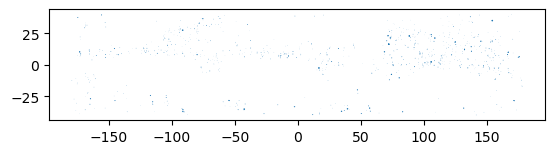

In [22]:
coloc_gdf.plot()

In [23]:
coloc_gdf.to_parquet("orcestra_coloc_ec_sounders.parquet")

In [26]:
coloc_gdf = gpd.read_parquet(
    "orcestra_coloc_ec_sounders.parquet",
)
coloc_gdf = coloc_gdf.set_geometry(coloc_gdf.geometry.buffer(0.5))

/tmp/ipykernel_213/362387011.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coloc_gdf = coloc_gdf.set_geometry(coloc_gdf.geometry.buffer(0.5))


Text(0.5, 1.0, 'Max precip [mm/hr]')

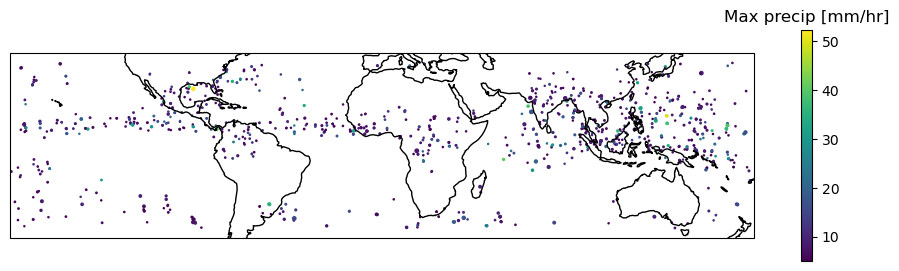

In [27]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax.coastlines()

points = coloc_gdf.plot("max_precip", ax=ax, legend=True)
colorbar_ax = fig.axes[-1] #to get the last axis of the figure, it's the colorbar axes
colorbar_ax.set_title("Max precip [mm/hr]")
